# Imports

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

# Loading env variables

In [4]:
load_dotenv()

True

# Define LLM

In [5]:
model = ChatGroq(
    model="qwen/qwen3-32b"    # other params...
)

# Define State

In [6]:
class BlogState(TypedDict):
     
     title : str
     outline : str
     content : str

# Creating Nodes

In [7]:
def create_oultine(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [8]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    Prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(Prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [9]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_oultine',create_oultine)
graph.add_node('create_blog',create_blog)

#edges
graph.add_edge(START,'create_oultine')
graph.add_edge('create_oultine','create_blog')
graph.add_edge('create_blog',END)

workflow = graph.compile()


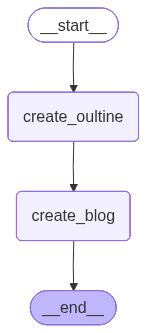

In [10]:
workflow

In [11]:
intial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

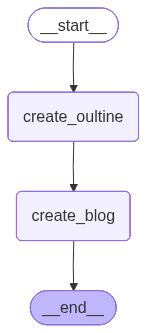

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())